In [1]:
using BayesSoundSource
using MCMCChains
using PythonPlot

In [5]:
using Turing
using LinearAlgebra
using Serialization
using CSV
using DataFrames

using KernelDensity
using Optim

function kde_mode(samples) 
    kde_est = kde(samples)
    f(x) = -pdf(kde_est, x[1]) 
    result = optimize(f, [mean(samples)])
    return Optim.minimizer(result)[1]
end 

microphone_coords = [
    [0.0, 0.0, 0.0],
    [-8.0, 0.0, 0.89],
    [0.0, 8.0, 1.65],
    [8.0, 0.0, 0.92],
    [0.0, -8.0, 1.64]
]

chn = deserialize("chn_joint.bin")


Chains MCMC chain (300×127×1 Array{Float64, 3}):

Iterations        = 151:1:450
Number of chains  = 1
Samples per chain = 300
Wall duration     = 700.64 seconds
Compute duration  = 700.64 seconds
parameters        = receivers[1, 1], receivers[2, 1], receivers[3, 1], receivers[1, 2], receivers[2, 2], receivers[3, 2], receivers[1, 3], receivers[2, 3], receivers[3, 3], receivers[1, 4], receivers[2, 4], receivers[3, 4], receivers[1, 5], receivers[2, 5], receivers[3, 5], sos, σ_toa, σ_tdoa, t[1], t[2], t[3], t[4], t[5], t[6], t[7], t[8], t[9], t[10], t[11], t[12], t[13], t[14], t[15], t[16], t[17], t[18], t[19], t[20], t[21], t[22], t[23], traj.ℓ, traj.σ_noise, traj.σ_rbf, traj.coords[1, 1], traj.coords[2, 1], traj.coords[3, 1], traj.coords[4, 1], traj.coords[5, 1], traj.coords[6, 1], traj.coords[7, 1], traj.coords[8, 1], traj.coords[9, 1], traj.coords[10, 1], traj.coords[11, 1], traj.coords[12, 1], traj.coords[13, 1], traj.coords[14, 1], traj.coords[15, 1], traj.coords[16, 1], traj.coords[

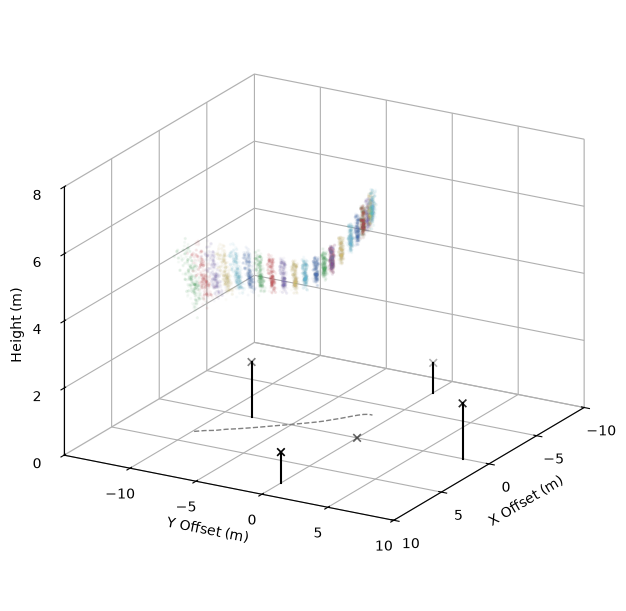

In [17]:
# using ColorSchemes
function to_rgb_string(c)
    r = round(Int, 255*c.r)
    g = round(Int, 255*c.g)
    b = round(Int, 255*c.b)
    return "rgb($r,$g,$b)"
end

Z = (size(group(chn, "traj.coords"), 2) ÷ 3)
traj = sample_traj(chn, 3, Z)
downsample = 1 #5

# function plot_chn(chn)
    fig = figure(figsize=(8, 6), constrained_layout=true)
    ax = fig.add_subplot(111, projection="3d")
    ax.set_proj_type("ortho") 
    ax.set_zlim(0, 8)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-15, 10)
    # ax.set_box_aspect((1, 1, 1))   # closest Matplotlib equivalent to equal aspect
    # ax.legend(false)
    ax.view_init(elev=20, azim=30)

    # ax.set_xticks([-10, -5, 0, 5, 10])
    # ax.set_yticks([-10, -5, 0, 5, 10])
    ax.set_xticks(-10:5:10)
    ax.set_yticks(-10:5:10)
    ax.set_zticks(0:2:8)
    ax.xaxis.pane.fill = false
    ax.yaxis.pane.fill = false
    ax.zaxis.pane.fill = false

    ax.set_xlabel("X Offset (m)")
    ax.set_ylabel("Y Offset (m)")
    ax.set_zlabel("Height (m)")
    ax.zaxis.labelpad=-1

    ax.grid(true, alpha=0.2, linewidth=0.6)

    colours = [
        "#4C72B0",
        "#55A868",
        "#C44E52",
        "#8172B3",
        "#CCB974",
        "#64B5CD"
    ]

    xs = Vector{Float64}(undef, Z)
    ys = Vector{Float64}(undef, Z)
    zs = Vector{Float64}(undef, Z)
    for i in 1:Z

        x = traj[i, 1, :]
        y = traj[i, 2, :]
        z = traj[i, 3, :]

        ax.scatter(
            x[1:downsample:end],
            y[1:downsample:end],
            z[1:downsample:end];
            marker="o",
            s=2,
            alpha=0.2,
            color=colours[i%6 + 1],
        )

        xs[i] = kde_mode(x)
        ys[i] = kde_mode(y)
        zs[i] = kde_mode(z)
    end

    # # 2D projection on z = 0 plane
    ax.plot(
        xs,
        ys,
        zeros(Z);
        label="2D Project",    
        color="gray",
        linestyle="--",
        alpha=1,
        linewidth=1, 
        zorder=0
    )

    # Receiver positions
    mx = getindex.(microphone_coords, 1)
    my = getindex.(microphone_coords, 2)
    mz = getindex.(microphone_coords, 3)

    ax.scatter(mx, my, mz; marker="x", label="Receivers",  s=30, linewidths=1.2, c=fill("black", 5), alpha=1)

    # Labels
    # ax.text(microphone_coords[1]..., raw"$\mathbf{x}_f$", va="bottom")
    # ax.text(microphone_coords[2]..., raw"$\mathbf{x}_1$", va="bottom")
    # ax.text(microphone_coords[3]..., raw"$\mathbf{x}_2$", va="bottom")
    # ax.text(microphone_coords[4]..., raw"$\mathbf{x}_3$", va="bottom")
    # ax.text(microphone_coords[5]..., raw"$\mathbf{x}_4$", va="bottom")

    # Vertical guide lines
    ax.plot([-8.0, -8.0], [0.0, 0.0], [0.89, 0.0], c="black")
    ax.plot([0.0, 0.0], [8.0, 8.0], [1.65, 0.0], c="black")
    ax.plot([8.0, 8.0], [0.0, 0.0], [0.92, 0.0], c="black")
    ax.plot([0.0, 0.0], [-8.0, -8.0], [1.64, 0.0], c="black")

    return fig
# end